In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil


drive_dir = '/content/drive/MyDrive/EuroSAT_Split_Physical'


local_dir = '/content/EuroSAT_Split_Physical'

if not os.path.exists(local_dir):
    print("🚚 Copying dataset from Drive to local disk (first time, may take a few minutes)...")
    shutil.copytree(drive_dir, local_dir)
    print("✅ Copy done.")
else:
    print("✅ Local copy already exists:", local_dir)


output_dir = local_dir
print("📂 Using dataset root:", output_dir)
print("Subdirs:", os.listdir(output_dir))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚚 Copying dataset from Drive to local disk (first time, may take a few minutes)...
✅ Copy done.
📂 Using dataset root: /content/EuroSAT_Split_Physical
Subdirs: ['train', 'valid', 'test']


In [ ]:

splits = ['train', 'test', 'valid']
for split in splits:
    split_path = os.path.join(output_dir, split)
    print(f"\nDataset partitioning:{split}")
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        num_images = len(os.listdir(class_path))
        print(f" - class {class_name}: {num_images} images")



数据集划分：train
 - 类别 PermanentCrop: 1750 张图片
 - 类别 AnnualCrop: 2100 张图片
 - 类别 Pasture: 1400 张图片
 - 类别 River: 1750 张图片
 - 类别 SeaLake: 2100 张图片
 - 类别 Industrial: 1750 张图片
 - 类别 Forest: 2100 张图片
 - 类别 Residential: 2100 张图片
 - 类别 Highway: 1750 张图片
 - 类别 HerbaceousVegetation: 2099 张图片

数据集划分：test
 - 类别 PermanentCrop: 375 张图片
 - 类别 AnnualCrop: 450 张图片
 - 类别 Pasture: 300 张图片
 - 类别 River: 375 张图片
 - 类别 SeaLake: 450 张图片
 - 类别 Industrial: 375 张图片
 - 类别 Forest: 450 张图片
 - 类别 Residential: 450 张图片
 - 类别 Highway: 375 张图片
 - 类别 HerbaceousVegetation: 450 张图片

数据集划分：valid
 - 类别 PermanentCrop: 375 张图片
 - 类别 AnnualCrop: 450 张图片
 - 类别 Pasture: 300 张图片
 - 类别 River: 375 张图片
 - 类别 SeaLake: 450 张图片
 - 类别 Industrial: 375 张图片
 - 类别 Forest: 450 张图片
 - 类别 Residential: 450 张图片
 - 类别 Highway: 375 张图片
 - 类别 HerbaceousVegetation: 451 张图片


In [ ]:
import cv2
import numpy as np

def load_image(image_path):

    # Read images from a path
    image = cv2.imread(image_path)


    if image is None:
        raise ValueError(f"Can't load images：{image_path}")


    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


    image = cv2.resize(image, (64, 64))

    return image


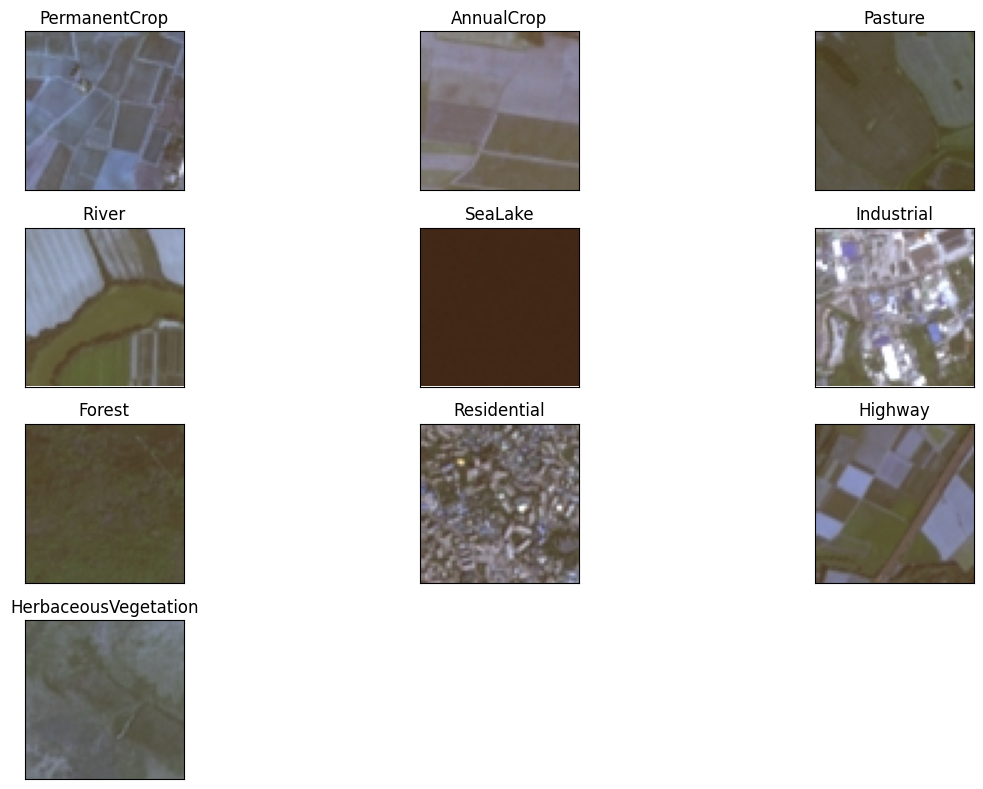

✅ 图片示例显示完成！


In [ ]:
import matplotlib.pyplot as plt
import cv2
import os


train_dir = os.path.join(output_dir, 'train')


samples_list = []
samples_label = []


for label in os.listdir(train_dir):
    class_path = os.path.join(train_dir, label)
    if os.path.isdir(class_path):

        sample_files = os.listdir(class_path)[:1]

        for sample_file in sample_files:
            img_path = os.path.join(class_path, sample_file)
            image = load_image(img_path)
            samples_list.append(image)
            samples_label.append(label)

# Maximum number of images to display
num_images = min(len(samples_list), 12)


plt.figure(figsize=(12, 8))

for i in range(num_images):
    plt.subplot(4, 3, i + 1)

    plt.imshow(cv2.cvtColor(samples_list[i], cv2.COLOR_BGR2RGB))
    plt.title(samples_label[i])
    plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

print("✅ Image example displayed!")


In [ ]:
import os

def statistic():
    labels = []
    num_images = []


    train_dir = os.path.join(output_dir, 'train')


    for class_name in os.listdir(train_dir):
        class_path = os.path.join(train_dir, class_name)

        if os.path.isdir(class_path):
            labels.append(class_name)
            num_images.append(len(os.listdir(class_path)))

    return labels, num_images


labels, counts = statistic()
for lbl, count in zip(labels, counts):
    print(f"{lbl}: {count} images")


PermanentCrop: 1750 张图片
AnnualCrop: 2100 张图片
Pasture: 1400 张图片
River: 1750 张图片
SeaLake: 2100 张图片
Industrial: 1750 张图片
Forest: 2100 张图片
Residential: 2100 张图片
Highway: 1750 张图片
HerbaceousVegetation: 2099 张图片


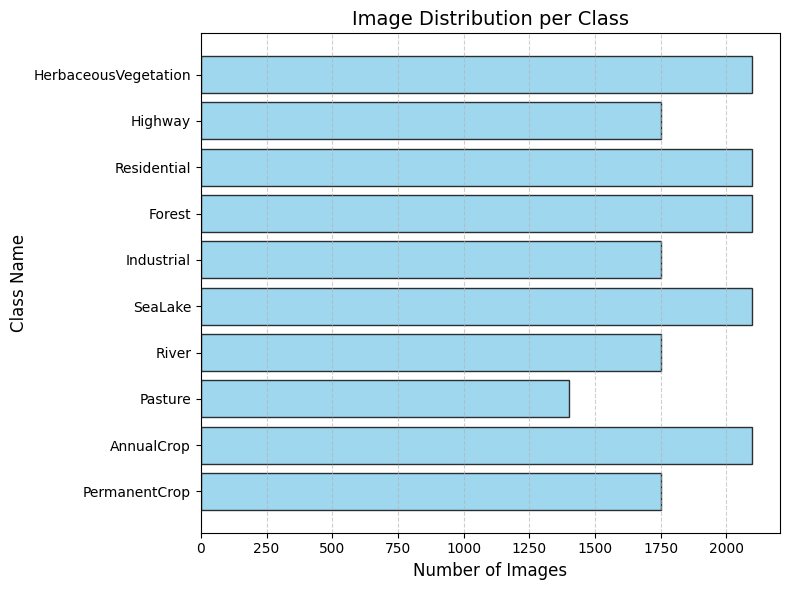

📊 Total number of images in dataset: 18899


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


labels, num_images = statistic()


y_pos = np.arange(len(labels))


plt.figure(figsize=(8, 6))
plt.barh(y_pos, num_images, color='skyblue', edgecolor='black', alpha=0.8)
plt.yticks(y_pos, labels, fontsize=10)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Class Name', fontsize=12)
plt.title('Image Distribution per Class', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


print(f"📊 Total number of images in dataset: {sum(num_images)}")


In [ ]:
import os
import numpy as np

def read_data(label2id, root_dir=os.path.join(output_dir, 'train')):

    X, Y = [], []
    missing_labels = []
    skipped_files = 0

    for label in sorted(os.listdir(root_dir)):
        class_path = os.path.join(root_dir, label)
        if not os.path.isdir(class_path):
            continue

        if label not in label2id:
            missing_labels.append(label)
            continue

        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)

            try:
                img = load_image(img_path)
            except Exception as e:
                skipped_files += 1
                print(f"⚠️ Skipped file (cannot load): {img_path} | {e}")
                continue

            X.append(img)
            Y.append(label2id[label])

    X = np.asarray(X)
    Y = np.asarray(Y)

    print(f"✅ Loaded {len(X)} images from '{root_dir}'.")
    print(f"🧭 Classes on disk used: {len(set(Y))} / expected {len(label2id)}.")
    if missing_labels:
        print(f"⚠️ Labels present on disk but missing in label2id (skipped): {missing_labels}")
    if skipped_files > 0:
        print(f"⚠️ Skipped files due to read errors: {skipped_files}")

    return X, Y


In [ ]:
import os
import numpy as np


def create_label_mapping(train_dir=os.path.join(output_dir, 'train')):

    classes = sorted(os.listdir(train_dir))
    return {class_name: idx for idx, class_name in enumerate(classes)}


def read_data(label2id, base_dir=os.path.join(output_dir, 'train')):

    X, Y = [], []


    for label, class_id in label2id.items():
        class_path = os.path.join(base_dir, label)

        if os.path.isdir(class_path):
            for img_file in os.listdir(class_path):
                img_path = os.path.join(class_path, img_file)

                img = load_image(img_path)
                X.append(img)
                Y.append(class_id)

    return np.array(X, dtype=object), np.array(Y)


train_dir = os.path.join(output_dir, 'train')
label2id = create_label_mapping(train_dir)


X, Y = read_data(label2id, base_dir=train_dir)

print(f" Number of images loaded: {len(X)}")
print(f" Number of labels: {len(Y)}")
print(f" Shape of first image: {X[0].shape if len(X) > 0 else 'No data'}")
print(f" Label ID of first image: {Y[0] if len(Y) > 0 else 'No data'}")
print(f" Class → ID mapping: {label2id}")


 Number of images loaded: 18899
 Number of labels: 18899
 Shape of first image: (64, 64, 3)
 Label ID of first image: 0
 Class → ID mapping: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In [ ]:
import cv2

print(f"🔍 OpenCV version: {cv2.__version__}")


print(f"✅ SIFT available: {hasattr(cv2, 'SIFT_create')}")


🔍 OpenCV version: 4.12.0
✅ SIFT available: True


In [ ]:
import cv2
import numpy as np

def extract_sift_features(X):

    image_descriptors = []


    sift = cv2.SIFT_create()

    for img in X:
        if img is None:
            print("⚠️ Warning: Invalid image, skipped...")
            image_descriptors.append(None)
            continue


        if img.dtype != np.uint8:
            img = img.astype(np.uint8)


        if len(img.shape) == 3 and img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


        kp, des = sift.detectAndCompute(img, None)

        if des is not None:
            image_descriptors.append(des)
        else:
            image_descriptors.append(np.zeros((1, 128)))

    print(f"✅ Extracted SIFT features from {len(image_descriptors)} images.")
    return image_descriptors


In [ ]:
import pickle


image_descriptors = extract_sift_features(X)


pickle.dump(image_descriptors, open('img_des.dump', 'wb'))


# image_descriptors = pickle.load(open('img_des.dump', 'rb'))

print(f"✅ Total images with extracted features: {len(image_descriptors)}")


if len(image_descriptors) > 0 and image_descriptors[0] is not None and len(image_descriptors[0]) > 0:
    print(f"🧭 Dimension of first descriptor: {image_descriptors[0][0].shape}")
else:
    print("⚠️ No features were extracted from the images.")


num_samples = min(10, len(image_descriptors))

print("\n🔹 Number of descriptors per image (first 10 samples):")
for i in range(num_samples):
    num_descriptors = len(image_descriptors[i]) if image_descriptors[i] is not None else 0
    print(f"  Image {i}: {num_descriptors} descriptors")


✅ Extracted SIFT features from 18899 images.
✅ Total images with extracted features: 18899
🧭 Dimension of first descriptor: (128,)

🔹 Number of descriptors per image (first 10 samples):
  Image 0: 1 descriptors
  Image 1: 9 descriptors
  Image 2: 18 descriptors
  Image 3: 1 descriptors
  Image 4: 3 descriptors
  Image 5: 5 descriptors
  Image 6: 5 descriptors
  Image 7: 10 descriptors
  Image 8: 1 descriptors
  Image 9: 8 descriptors


In [ ]:
# Summarize the SIFT features of all images into a single list
all_descriptors = []

for descriptors in image_descriptors:
    if descriptors is not None:
        for des in descriptors:
            all_descriptors.append(des)

print(f"✅ Total number of SIFT descriptors: {len(all_descriptors)}")


✅ Total number of SIFT descriptors: 353162


In [ ]:
from sklearn.cluster import KMeans
import numpy as np

def kmeans_bow(image_descriptors, num_clusters=100):

    # Concatenate all valid descriptors into a large matrix
    valid_desc = [desc for desc in image_descriptors if desc is not None and len(desc) > 0]

    if len(valid_desc) == 0:
        print("⚠️ No valid descriptors found. KMeans cannot be trained.")
        return None

    all_descriptors = np.vstack(valid_desc)

    print(f"✅ Total descriptors used for clustering: {len(all_descriptors)}")

    print(f"🔹 Training KMeans with {num_clusters} clusters...")
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans.fit(all_descriptors)

    print("✅ KMeans clustering completed successfully!")
    print(f"📚 Vocabulary size (BoVW dictionary): {num_clusters}")

    return kmeans.cluster_centers_


In [ ]:
import pickle
import os

# Set the number of BoVW clusters (adjustable from 100 to 500 depending on data complexity)
num_clusters = 100


if not os.path.isfile('bow_dictionary.pkl'):
    print("🔹 Training new BoW dictionary using KMeans...")
    BoW = kmeans_bow(image_descriptors, num_clusters)
    pickle.dump(BoW, open('bow_dictionary.pkl', 'wb'))
    print("✅ BoW dictionary saved to 'bow_dictionary.pkl'.")
else:
    print("📂 Loading existing BoW dictionary from file...")
    BoW = pickle.load(open('bow_dictionary.pkl', 'rb'))
    print("✅ BoW dictionary loaded successfully.")


print(f"📊 Vocabulary size (number of clusters): {len(BoW)}")
print(f"🧩 Data type of first word vector: {type(BoW[0])}")
print(f"📏 Dimension of each word vector: {BoW[0].shape}")


🔹 Training new BoW dictionary using KMeans...
✅ Total descriptors used for clustering: 353162
🔹 Training KMeans with 100 clusters...
✅ KMeans clustering completed successfully!
📚 Vocabulary size (BoVW dictionary): 100
✅ BoW dictionary saved to 'bow_dictionary.pkl'.
📊 Vocabulary size (number of clusters): 100
🧩 Data type of first word vector: <class 'numpy.ndarray'>
📏 Dimension of each word vector: (128,)


In [ ]:
import numpy as np
from scipy.spatial.distance import cdist

def create_features_bow(image_descriptors, BoW, num_clusters):

    X_features = []

    print("🔄 Generating BoW features for all images...")

    for i, descriptors in enumerate(image_descriptors):

        features = np.zeros(num_clusters)


        if descriptors is not None and len(descriptors) > 0:
            # Calculate the distance between all descriptors of the image and each "word" in the dictionary.
            distance = cdist(descriptors, BoW)


            argmin = np.argmin(distance, axis=1)

            for j in argmin:
                features[j] += 1

        X_features.append(features)

# Print progress every 1000 images processed.
        if (i + 1) % 1000 == 0:
            print(f"✅ Processed {i+1}/{len(image_descriptors)} images...")

    print("✅ Finished generating BoW feature vectors!")

    return np.array(X_features)


In [ ]:
# Use the BoW dictionary to convert all images into fixed-length feature vectors
X_features = create_features_bow(image_descriptors, BoW, num_clusters)


print(f"✅ Total number of image feature vectors: {len(X_features)}")


print(f"🧩 BoW feature vector of first image:\n{X_features[0]}")


print(f"📊 Sum of histogram values (should ≈ number of descriptors): {sum(X_features[0])}")


print(f"🔹 Number of SIFT descriptors in first image: {image_descriptors[0].shape[0]}")


🔄 Generating BoW features for all images...
✅ Processed 1000/18899 images...
✅ Processed 2000/18899 images...
✅ Processed 3000/18899 images...
✅ Processed 4000/18899 images...
✅ Processed 5000/18899 images...
✅ Processed 6000/18899 images...
✅ Processed 7000/18899 images...
✅ Processed 8000/18899 images...
✅ Processed 9000/18899 images...
✅ Processed 10000/18899 images...
✅ Processed 11000/18899 images...
✅ Processed 12000/18899 images...
✅ Processed 13000/18899 images...
✅ Processed 14000/18899 images...
✅ Processed 15000/18899 images...
✅ Processed 16000/18899 images...
✅ Processed 17000/18899 images...
✅ Processed 18000/18899 images...
✅ Finished generating BoW feature vectors!
✅ Total number of image feature vectors: 18899
🧩 BoW feature vector of first image:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 

In [ ]:
print(len(X_features))
print(len(Y))

18899
18899


In [ ]:
#Use the predefined data partitioning: train / test / valid

# Create a category mapping (category name → ID)
label2id = create_label_mapping(os.path.join(output_dir, 'train'))

# Read the training set, test set, and validation set respectively
X_train, Y_train = read_data(label2id, base_dir=os.path.join(output_dir, 'train'))
X_test,  Y_test  = read_data(label2id, base_dir=os.path.join(output_dir, 'test'))
X_valid, Y_valid = read_data(label2id, base_dir=os.path.join(output_dir, 'valid'))


print(f"✅ Number of samples in training set: {len(X_train)}")
print(f"✅ Number of samples in test set: {len(X_test)}")
print(f"✅ Number of samples in validation set: {len(X_valid)}")


✅ Number of samples in training set: 18899
✅ Number of samples in test set: 4050
✅ Number of samples in validation set: 4051


✅ Extracted SIFT features from 18899 images.
✅ Extracted SIFT features from 4051 images.
✅ Extracted SIFT features from 4050 images.
🔄 Generating BoW features for all images...
✅ Processed 1000/18899 images...
✅ Processed 2000/18899 images...
✅ Processed 3000/18899 images...
✅ Processed 4000/18899 images...
✅ Processed 5000/18899 images...
✅ Processed 6000/18899 images...
✅ Processed 7000/18899 images...
✅ Processed 8000/18899 images...
✅ Processed 9000/18899 images...
✅ Processed 10000/18899 images...
✅ Processed 11000/18899 images...
✅ Processed 12000/18899 images...
✅ Processed 13000/18899 images...
✅ Processed 14000/18899 images...
✅ Processed 15000/18899 images...
✅ Processed 16000/18899 images...
✅ Processed 17000/18899 images...
✅ Processed 18000/18899 images...
✅ Finished generating BoW feature vectors!
🔄 Generating BoW features for all images...
✅ Processed 1000/4051 images...
✅ Processed 2000/4051 images...
✅ Processed 3000/4051 images...
✅ Processed 4000/4051 images...
✅ Fin

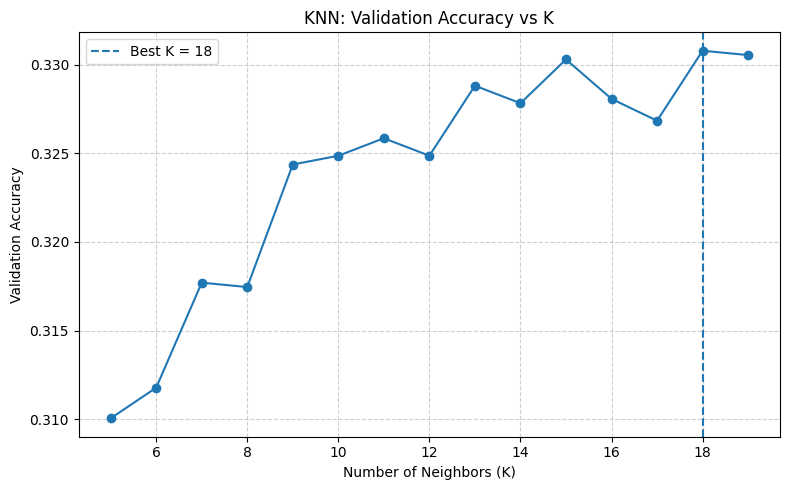

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

# 1) Extract SIFT features from each subset (if not mentioned before)
train_desc = extract_sift_features(X_train)
valid_desc = extract_sift_features(X_valid)
test_desc  = extract_sift_features(X_test)


# 3) Convert the SIFT features of each image into a BoW histogram (two-dimensional matrix).
X_train_features = create_features_bow(train_desc, BoW, num_clusters)
X_valid_features = create_features_bow(valid_desc, BoW, num_clusters)
X_test_features  = create_features_bow(test_desc,  BoW, num_clusters)


X_train_features = normalize(X_train_features, norm='l2')
X_valid_features = normalize(X_valid_features, norm='l2')
X_test_features  = normalize(X_test_features,  norm='l2')

#5) Select the best K using the validation set
k_values = range(5,20)
accuracies = []
best_k = None
best_acc = 0.0

print("🔍 Searching for best K using validation set...")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_features, Y_train)

    Y_valid_pred = knn.predict(X_valid_features)
    acc = accuracy_score(Y_valid, Y_valid_pred)
    accuracies.append(acc)
    print(f"   K = {k:<2d} → Validation Accuracy = {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_k = k

print(f"\n✅ Best K found on validation set: {best_k}  →  Accuracy: {best_acc:.4f}")

#6) Perform final evaluation on the test set using the optimal K.
final_knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
final_knn.fit(X_train_features, Y_train)
Y_test_pred = final_knn.predict(X_test_features)
test_acc = accuracy_score(Y_test, Y_test_pred)
print(f"📊 Final Test Accuracy (using best K={best_k}): {test_acc:.4f}")


plt.figure(figsize=(8, 5))
plt.plot(list(k_values), accuracies, marker='o', linestyle='-')
plt.axvline(best_k, linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Validation Accuracy')
plt.title('KNN: Validation Accuracy vs K')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


📊 Classification Report (per class):
                      precision    recall  f1-score   support

          AnnualCrop     0.1938    0.8200    0.3135       450
              Forest     0.1351    0.0333    0.0535       450
HerbaceousVegetation     0.3316    0.2844    0.3062       450
             Highway     0.4733    0.3307    0.3893       375
          Industrial     0.5400    0.8640    0.6646       375
             Pasture     0.2240    0.0933    0.1318       300
       PermanentCrop     0.4603    0.1547    0.2315       375
         Residential     0.7377    0.6689    0.7016       450
               River     0.3438    0.1173    0.1750       375
             SeaLake     0.0000    0.0000    0.0000       450

            accuracy                         0.3435      4050
           macro avg     0.3440    0.3367    0.2967      4050
        weighted avg     0.3402    0.3435    0.2977      4050

✅ Overall Test Accuracy: 0.3435


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


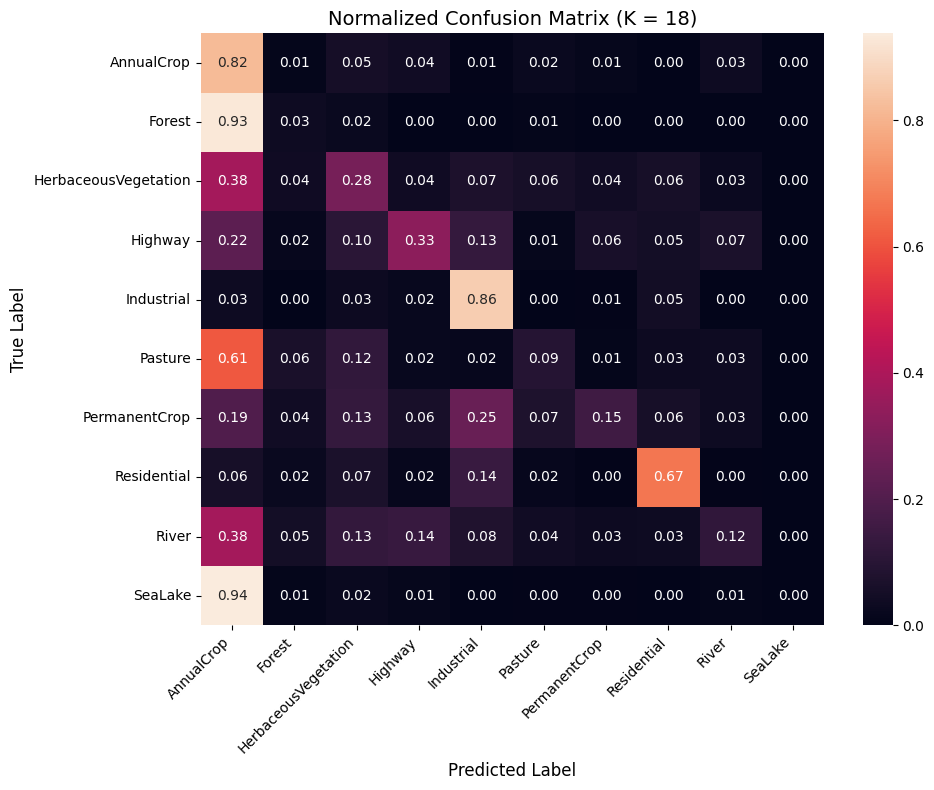

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


id2label = {v: k for k, v in label2id.items()}
class_names = [id2label[i] for i in range(len(id2label))]
label_order = list(range(len(class_names)))


knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_best.fit(X_train_features, Y_train)
Y_pred = knn_best.predict(X_test_features)


print("📊 Classification Report (per class):")
print(classification_report(Y_test, Y_pred, target_names=class_names, digits=4))


acc = accuracy_score(Y_test, Y_pred)
print(f"✅ Overall Test Accuracy: {acc:.4f}")


cm = confusion_matrix(Y_test, Y_pred, labels=label_order)
cm_norm = cm.astype(np.float64) / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Normalized Confusion Matrix (K = {best_k})', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



原图大小: 2500 x 1131


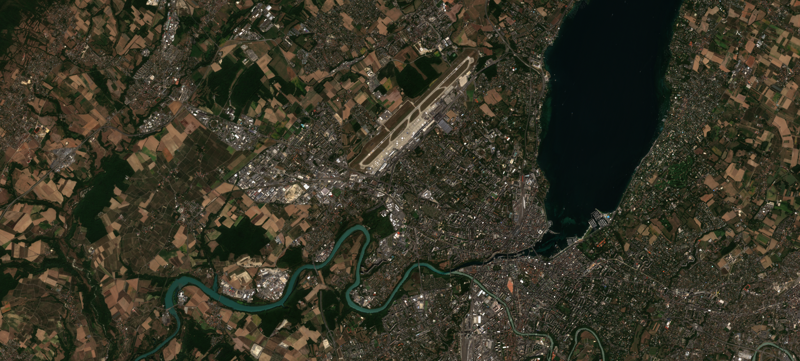

用于网格的区域大小: 2496 x 1088
patch 网格: 17 行 x 39 列，共 663 个 patch
✅ patch 提取完成（用于 SIFT+BoW+KNN）: 663


In [ ]:

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


raw_image_path = "/content/drive/MyDrive/2025-08-18-00_00_2025-08-18-23_59_Sentinel-2_L2A_True_Color.png"

big_img = Image.open(raw_image_path).convert("RGB")
W, H = big_img.size
print(f"Original size: {W} x {H}")


display(big_img.resize((min(W, 800), int(H * min(W, 800) / W))))




patch_size = 64
stride = patch_size


n_cols = W // patch_size
n_rows = H // patch_size

crop_w = n_cols * patch_size
crop_h = n_rows * patch_size

print(f"Area size for the grid: {crop_w} x {crop_h}")
print(f"patch grid: {n_rows}  x {n_cols} ， {n_rows * n_cols} patchs")


big_img_cropped = big_img.crop((0, 0, crop_w, crop_h))


patches_pil = []
patches_np  = []

for r in range(n_rows):
    for c in range(n_cols):
        left   = c * stride
        upper  = r * stride
        right  = left + patch_size
        lower  = upper + patch_size
        patch  = big_img_cropped.crop((left, upper, right, lower))  # PIL.Image

        patches_pil.append(patch)
        patches_np.append(np.array(patch))  # 64x64x3, uint8

print("✅ patch Extraction complete (for SIFT+BoW+KNN):", len(patches_np))


In [ ]:

from sklearn.preprocessing import normalize
import numpy as np

# 1) Extract SIFT features from all patches (reuse your previous function)
print("🔍 Extract SIFT features from each patch...")
patch_descriptors = extract_sift_features(patches_np)

# 2) Map SIFT descriptors to BoW histogram features
print("🔄 Convert SIFT descriptors to BoW histogram features..")
X_patches_bow = create_features_bow(patch_descriptors, BoW, num_clusters)

# 3) L2 normalization (to maintain consistency with training)
X_patches_bow = normalize(X_patches_bow, norm='l2')

# 4) Use your previously trained KNN model for prediction.

print("🤖 Use KNN to classify each patch...")
patch_preds = knn_best.predict(X_patches_bow)
patch_preds = np.array(patch_preds)

print("✅ SIFT+BoW+KNN patch-level prediction complete, number of predictions:", len(patch_preds))

# 5) Reshape into a classification grid of (n_rows, n_cols)
pred_grid_sift = patch_preds.reshape(n_rows, n_cols)
print("pred_grid_sift shape:", pred_grid_sift.shape)


🔍 提取每个 patch 的 SIFT 特征...
✅ Extracted SIFT features from 663 images.
🔄 将 SIFT 描述子转换为 BoW 直方图特征...
🔄 Generating BoW features for all images...
✅ Finished generating BoW feature vectors!
🤖 使用 KNN 对每个 patch 分类...
✅ SIFT+BoW+KNN patch 级预测完成，预测数量： 663
pred_grid_sift shape: (17, 39)


pred_full_res_sift shape: (1088, 2496)


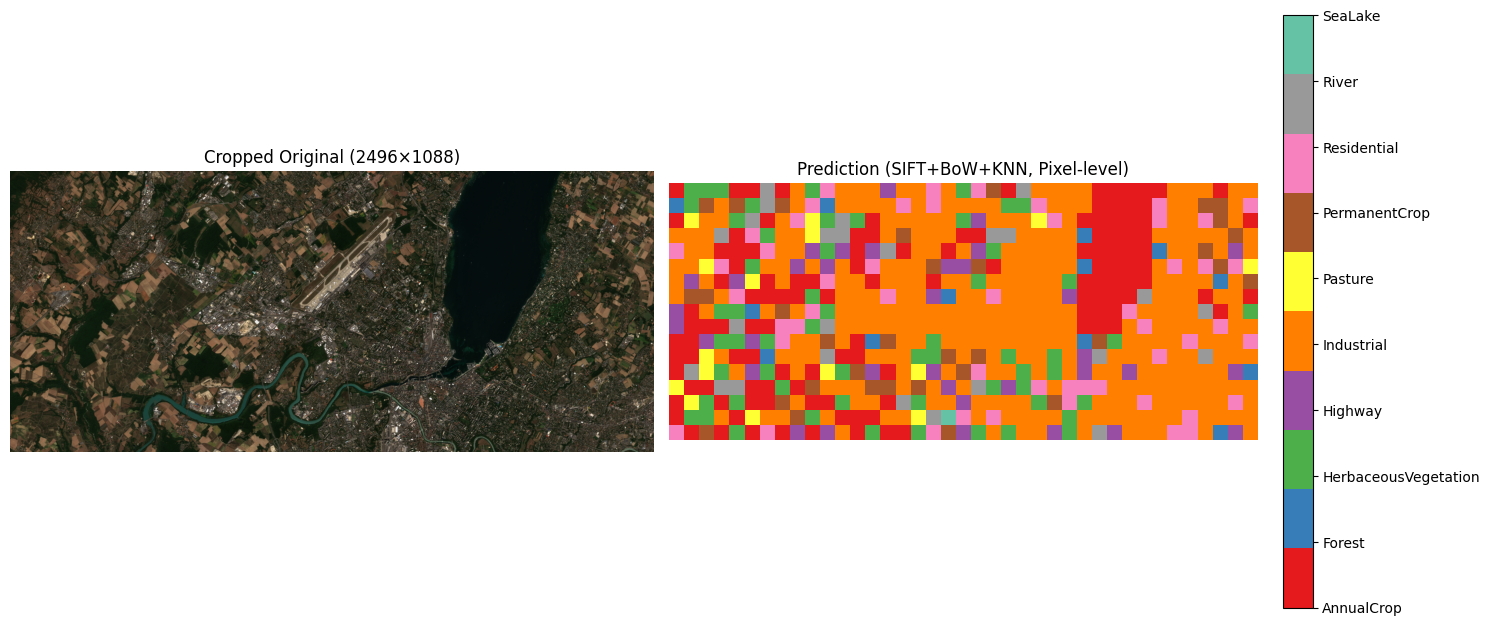

📝 原图尺寸： (2500, 1131)
✂️ 裁剪后尺寸（SIFT+KNN）: (2496, 1088)
🎉 已保存对比图：comparison_sift_bow_knn_big.png


In [ ]:

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# 1) Extend patch prediction to the pixel level
patch_size = 64
pred_full_res_sift = np.kron(pred_grid_sift, np.ones((patch_size, patch_size), dtype=int))
crop_h_sift, crop_w_sift = pred_full_res_sift.shape

print("pred_full_res_sift shape:", pred_full_res_sift.shape)

# 2) Crop the original image to ensure it is perfectly aligned with the predicted image.
big_img_cropped_sift = big_img.crop((0, 0, crop_w_sift, crop_h_sift))

# 3) Prepare a colormap (use the same colors as before for easy comparison with the ResNet image).
color_list = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
    "#ffff33", "#a65628", "#f781bf", "#999999", "#66c2a5",
    "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f",
    "#e5c494", "#b3b3b3"
]
assert len(color_list) >= len(class_names)
cmap = ListedColormap(color_list[:len(class_names)])


plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(big_img_cropped_sift)
plt.title(f"Cropped Original ({crop_w_sift}×{crop_h_sift})", fontsize=12)
plt.axis("off")

plt.subplot(1, 2, 2)
im = plt.imshow(pred_full_res_sift, cmap=cmap,
                vmin=0, vmax=len(class_names)-1,
                interpolation="nearest")
plt.title("Prediction (SIFT+BoW+KNN, Pixel-level)", fontsize=12)
plt.axis("off")


cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_ticks(range(len(class_names)))
cbar.set_ticklabels(class_names)

plt.tight_layout()


plt.savefig("comparison_sift_bow_knn_big.png", dpi=300)
plt.show()

print("📝 Original Size：", (W, H))
print("✂️ Post-cut dimensions (SIFT+KNN):", (crop_w_sift, crop_h_sift))
print("🎉 Comparison image saved: comparison_sift_bow_knn_big.png")


In [ ]:
# Categorical Statistics of This Large Image (by Patch Quantity & Proportion)
import numpy as np

counts = np.bincount(patch_preds, minlength=len(class_names))
total_patches = counts.sum()

print("📊 SIFT+BoW+KNN large image classification results (statistics by patch):")
for cls_id, cnt in enumerate(counts):
    cls_name = class_names[cls_id]
    ratio = (cnt / total_patches * 100) if total_patches > 0 else 0.0
    print(f"  - {cls_name:15s}: {cnt:5d} patches  ({ratio:6.2f}%)")

print(f"\n📦 Total patches in image: {total_patches}")


📊 SIFT+BoW+KNN 大图分类结果（按 patch 统计）：
  - AnnualCrop     :   124 patches  ( 18.70%)
  - Forest         :    13 patches  (  1.96%)
  - HerbaceousVegetation:    58 patches  (  8.75%)
  - Highway        :    35 patches  (  5.28%)
  - Industrial     :   308 patches  ( 46.46%)
  - Pasture        :    15 patches  (  2.26%)
  - PermanentCrop  :    33 patches  (  4.98%)
  - Residential    :    51 patches  (  7.69%)
  - River          :    25 patches  (  3.77%)
  - SeaLake        :     1 patches  (  0.15%)

📦 Total patches in image: 663
